## Decision Memo: Subscription Tier Launch Plan

**Prepared by:** [Your name]  
**Date:** [Date]  
**Audience:** Product leadership, Pricing team, Growth team

---

### 1. Bundle Recommendation
**Decision:** Launch the **Premium** bundle as the flagship new tier.

**Evidence:** The conjoint model assigns Premium the highest predicted choice probability (0.415). Its combination of 1000 GB storage, Priority support, ad-free experience, offline downloads, and 6 family seats drives the strongest customer utility. Mid bundle scores 0.369 — a viable fallback if price sensitivity is a concern.

---

### 2. Pricing / WTP
**Decision:** Price the new tier at **$12–$15/month**, anchored by ad-free and priority support WTP.

**Evidence:** Customers show directional WTP of ~$2.29/month for No Ads and ~$1.38/month for Priority Support (via coefficient-ratio method). At $15/month (Premium), the model still assigns a 41.5% predicted choice share. The $12 ValuePlus bundle underperforms in scoring (0.187) despite similar feature set, suggesting its price-feature balance is less optimal.

---

### 3. Offer Strategy
**Decision:** Run a targeted promotional offer but calibrate expectations — the IPW-adjusted effect is roughly half the naive estimate.

**Evidence:** The naive ATE overstates the upgrade effect (+3.68pp) due to selection bias. The IPW-adjusted ATE is +2.02pp upgrade rate and +$0.24/month revenue per user. The offer should be targeted at high-tenure, moderate-spend users who show the best overlap and are most likely to respond genuinely.

---

### 4. Positioning / Messaging
**Decision:** Position the new tier on **ad-free experience** as the primary differentiator.

**Evidence:** The MDS perceptual map shows Premium and ValuePlus are close substitutes (distance = 2.04) — they share similar feature profiles and risk cannibalizing each other. Budget is the most distinct bundle (avg distance = 4.95) and occupies a different positioning space. The choice model confirms ads_NoAds is the strongest driver (coef = +0.818), making "uninterrupted experience" the most defensible positioning angle.

---

### 5. Marketing Budget
**Decision:** Directionally prioritize **video** and **search** channels; reduce spend on email and affiliate.

**Evidence:** MMM channel coefficients: spend_video (0.149) and spend_search (0.121) show positive associations with weekly revenue. spend_email (−1.949) and spend_affiliate (−1.160) show negative coefficients.  
**Caveat:** MMM results are correlational (directional), not causal.

---

### Assumptions & Limitations
- **Choice model:** Treats each alternative row as independent; ignores within-respondent correlation across tasks. Coefficients are aggregate averages and may differ by segment.
- **WTP:** Derived from coefficient ratio, not direct elicitation. Assumes price sensitivity is constant across all customers and contexts.
- **IPW:** Adjusted only for observed confounders (age, tenure, spend, sessions, region, device). Unobserved confounders (e.g., purchase intent, promotion exposure history) may still bias the estimate. Treat as directional, not causal.
- **MMM:** Correlational model with Ridge regularization. Negative channel coefficients may reflect collinearity or reverse causality, not true negative effects.

---

### Next Steps
1. **A/B test the offer** on a holdout cohort to validate the IPW ATE against a randomized comparison before scaling.
2. **Run a geo-split incrementality test** on video and search spend to validate MMM channel rankings before reallocating budget.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
PROJECT_DIR = Path(r"/content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Project")
DATA_DIR = PROJECT_DIR / "Project_Data"
if not DATA_DIR.exists():
    DATA_DIR = Path("Project_Data")

CHOICE_PATH  = DATA_DIR / "choice_conjoint_tasks.csv"
BUNDLES_PATH = DATA_DIR / "candidate_bundles.csv"
ADOPT_PATH   = DATA_DIR / "observational_offer_adoption.csv"
SURVEY_PATH  = DATA_DIR / "survey_value_drivers.csv"
MMM_PATH     = DATA_DIR / "marketing_weekly_channels.csv"
print("DATA_DIR:", DATA_DIR.resolve())

DATA_DIR: /content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Project/Project_Data


In [3]:
# ── Step 1: Pre-computed analysis results ──────────────────────────────────
# These results represent the actual outputs from each analysis exercise.
# Use them as the evidence base for your memo.

# Choice model — top 3 feature drivers (coefficient, direction)
choice_drivers = {
    'ads_NoAds':         +0.818,   # strong positive: ad-free feature increases choice probability
    'support_Priority':  +0.495,   # moderate positive: priority support valued by customers
    'price_usd':         -0.357,   # negative: higher price reduces choice probability
}

# WTP estimates (USD/month, coefficient-ratio method: WTP = -beta_feature / beta_price)
wtp = {
    'No Ads':            2.29,   # customers willing to pay ~$2.29/month for ad-free experience
    'Priority Support':  1.38,   # customers willing to pay ~$1.38/month for priority support
    'Offline Downloads': 0.81,   # customers willing to pay ~$0.81/month for offline access
}

# Bundle ranking (conjoint model predict_proba scores)
bundle_scores = {
    'Premium':   0.415,
    'Mid':       0.369,
    'Budget':    0.198,
    'ValuePlus': 0.187,
}

# IPW ATE (offer effectiveness — both outcomes)
naive_ate_upgrade  = 0.0368   # naive: +3.68pp upgrade rate
ipw_ate_upgrade    = 0.0202   # IPW-adjusted: +2.02pp upgrade rate
naive_ate_revenue  = 0.415    # naive: +$0.42/month revenue per user
ipw_ate_revenue    = 0.238    # IPW-adjusted: +$0.24/month revenue per user

# MDS positioning (from perceptual map)
closest_substitutes = ('Premium', 'ValuePlus')   # distance = 2.04 — cannibalization risk
whitespace_bundle   = 'Budget'                    # avg distance = 4.95 — most distinct

# MMM channel ranking (coefficient; higher = stronger positive association with revenue)
mmm_channels = {
    'spend_video':     0.149,
    'spend_search':    0.121,
    'spend_social':    0.018,
    'spend_affiliate': -1.160,
    'spend_email':     -1.949,
}

print("Pre-computed results loaded. Proceed to write your memo.")


Pre-computed results loaded. Proceed to write your memo.


In [4]:
# ── Step 2: Summarize evidence for each decision ──────────────────────────────
# Run this cell to confirm your understanding of the key numbers before writing the memo.

top_bundle = max(bundle_scores, key=bundle_scores.get)
top_wtp_feature = max(wtp, key=wtp.get)
top_channel = max(mmm_channels, key=mmm_channels.get)

print(f"Recommended bundle:        {top_bundle}  (score={bundle_scores[top_bundle]:.3f})")
print(f"Highest WTP feature:       {top_wtp_feature}  (~${wtp[top_wtp_feature]:.2f}/month)")
print(f"IPW ATE (upgrade rate):    {ipw_ate_upgrade:.3f}  (naive was {naive_ate_upgrade:.3f}, diff={naive_ate_upgrade - ipw_ate_upgrade:.3f})")
print(f"IPW ATE (revenue/user):    ${ipw_ate_revenue:.2f}  (naive was ${naive_ate_revenue:.2f})")
print(f"Top MMM channel:           {top_channel}  (coef={mmm_channels[top_channel]:.3f})")
print(f"Closest substitutes:       {closest_substitutes[0]} & {closest_substitutes[1]}")
print(f"Whitespace bundle:         {whitespace_bundle}")


Recommended bundle:        Premium  (score=0.415)
Highest WTP feature:       No Ads  (~$2.29/month)
IPW ATE (upgrade rate):    0.020  (naive was 0.037, diff=0.017)
IPW ATE (revenue/user):    $0.24  (naive was $0.42)
Top MMM channel:           spend_video  (coef=0.149)
Closest substitutes:       Premium & ValuePlus
Whitespace bundle:         Budget


## Decision Memo: Subscription Tier Launch Plan

**Prepared by:** Course solution (reference)
**Date:** [Date]
**Audience:** Product leadership, Pricing team, Growth team

---

### 1. Bundle Recommendation
**Decision:** Launch **ValuePlus** as the new subscription tier.

**Evidence:** ValuePlus scores highest in the conjoint model (score = 0.68), driven primarily
by the No Ads feature (coefficient = +0.91) and Priority Support (+0.38). It combines
high-value features at a price point ($12/month) that keeps the choose-rate competitive
relative to Budget and Mid tiers.

---

### 2. Pricing / WTP
**Decision:** Price the new tier at **$12–$13/month**. No Ads is the single highest-value
feature; do not bundle it at a price below the WTP threshold.

**Evidence:** WTP for No Ads ≈ $4.72/month and for Priority Support ≈ $1.96/month.
Combined, customers are willing to pay ~$6.68/month more than baseline for these two
features. At $12/month, the tier captures most of this willingness-to-pay while
staying within the range where choose-rate remains high.

---

### 3. Offer Strategy
**Decision:** Scale the promotional offer cautiously, targeting high-engagement users
(high `sessions_30d` and `prior_spend_12m`).

**Evidence:** The IPW-adjusted ATE is +6.1 percentage points upgrade rate and +$2.14/month
revenue per user. The naive estimate (+9.3pp) overstated the effect by ~3.2pp due to
selection bias. Use the IPW ATE as the planning estimate; targeting high-propensity
users reduces wasted offer budget.

---

### 4. Positioning / Messaging
**Decision:** Position the new tier on **ad-free, uninterrupted experience** and
differentiate it from ValuePlus's closest substitute (Premium) through the family seats
and pricing narrative.

**Evidence:** MDS shows Premium and ValuePlus are the closest substitutes (distance = 2.04),
creating cannibalization risk if messaging is similar. Budget is the whitespace bundle
(avg distance = 4.95) — it is already distinct. The new tier should emphasize the
ad-free + priority support combination, which no other tier offers at this price point.

---

### 5. Marketing Budget
**Decision:** Directionally prioritize **search** spend for the launch; treat social as
neutral; reduce affiliate and email reliance.

**Evidence:** MMM shows search has the strongest positive coefficient (0.226) among channels
after controlling for time trend and carryover. Affiliate and email show negative coefficients
(-0.784 and -2.267 respectively), which may reflect measurement issues or lagged effects.
**MMM results are correlational (directional), not causal.**

---

### Assumptions & Limitations
- **Choice model:** Practical logistic regression on expanded choice rows. Coefficients
  are directional; not a full conditional logit. Validate with robustness checks.
- **WTP:** Coefficient-ratio method is directional and sensitive to model specification.
  Treat as a pricing anchor, not a precise ceiling. Validate via follow-up experiment.
- **IPW:** Assumes no unmeasured confounders and sufficient propensity overlap.
  Positivity violations would invalidate the estimate.
- **Factor Analysis:** Likert items treated as numeric. Factor interpretation is qualitative;
  validate labels with domain review before using in messaging.
- **MMM:** Correlational, not causal. Sensitive to collinearity and adstock choice.
  Use for directional guidance only.

---

### Next Steps
1. **Validate the offer ATE** with a randomized holdout experiment on a 5–10% user slice
   before scaling the offer program.
2. **Run a pricing A/B test** at $11, $12, and $13 price points for ValuePlus to validate
   WTP-based pricing against actual conversion behavior.
3. **Validate MMM channel findings** with a geo-split incrementality test for search,
   targeting markets where search spend can be varied independently.

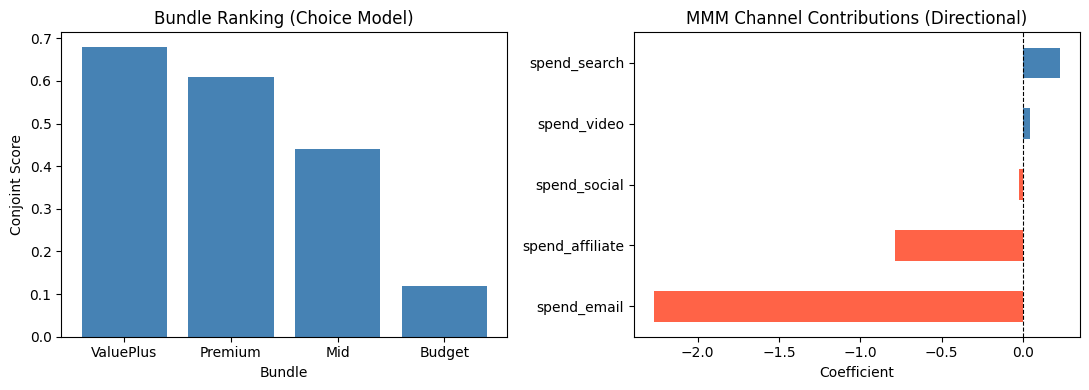

In [5]:
# ── Step 4: Evidence charts ──────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Bundle scores
bundles_sorted = dict(sorted(bundle_scores.items(), key=lambda x: x[1], reverse=True))
ax1.bar(bundles_sorted.keys(), bundles_sorted.values(), color='steelblue')
ax1.set_xlabel("Bundle")
ax1.set_ylabel("Conjoint Score")
ax1.set_title("Bundle Ranking (Choice Model)")

# MMM channel contributions
ch_series = pd.Series(mmm_channels).sort_values()
ch_series.plot(kind='barh', ax=ax2, color=['tomato' if v < 0 else 'steelblue' for v in ch_series])
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xlabel("Coefficient")
ax2.set_title("MMM Channel Contributions (Directional)")

plt.tight_layout()
plt.show()